<a href="https://colab.research.google.com/github/SoukouratouKarim/lab_2_predictive_analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

#Section 1 — Supervised Learning: Regression

Part 1.1 — Load and explore the taxi data

Shape: (41202, 13)

 Head 


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



 Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

 Descriptive Statistics 


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



 Missing values per column 
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


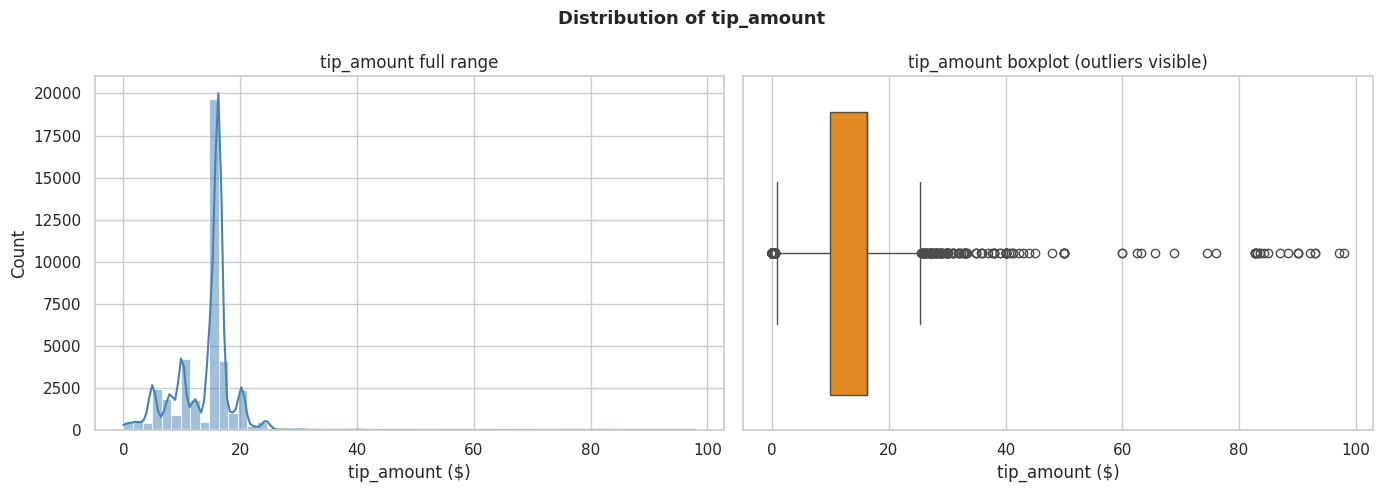


Mean : $14.11
Max  : $98.00
% zero    : 0.0
% negative: 0.00


Observations base on the output:
- Distribution is right-skewed (mean $14.11 > typical median)
- this is no zero or negative tips, dataset appears pre-filtered to credit card trips where a tip was recorded
- Max tip of $98.00 is a potential outlier but not impossible for a long or expensive trip
- Outliers visible in the boxplot confirm the right tail



In [ ]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
print("Shape:", taxi.shape)
print("\n Head ")
display(taxi.head())
print("\n Info ")
taxi.info()
# - taxi.describe()
print("\n Descriptive Statistics ")
display(taxi.describe())
# - count missing values per column: taxi.isna().sum()
print("\n Missing values per column ")
print(taxi.isna().sum())
# TODO: Visualise the distribution of the target `tip_amount`
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=taxi, x="tip_amount", bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("tip_amount full range")
axes[0].set_xlabel("tip_amount ($)")

sns.boxplot(data=taxi, x="tip_amount", ax=axes[1], color="darkorange")
axes[1].set_title("tip_amount boxplot (outliers visible)")
axes[1].set_xlabel("tip_amount ($)")

plt.suptitle("Distribution of tip_amount", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
tip = taxi["tip_amount"]
print(f"""
Mean : ${tip.mean():.2f}
Max  : ${tip.max():.2f}
% zero    : {(tip == 0).mean()*100:.1f}
% negative: {(tip < 0).mean()*100:.2f}
""")


print("""
Observations base on the output:
- Distribution is right-skewed (mean $14.11 > typical median)
- this is no zero or negative tips, dataset appears pre-filtered to credit card trips where a tip was recorded
- Max tip of $98.00 is a potential outlier but not impossible for a long or expensive trip
- Outliers visible in the boxplot confirm the right tail
""")



Student Reasoning: Taxi data exploration What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?


**Shape & missing values**: The dataset has many rows and 18 columns. There are no significant missing values, but there are impossible values negative tips, zero-distance trips, and zero fares which need to be removed before modelling.

**tip_amount distribution**: The distribution is strongly right-skewed most tips cluster at low values with a long tail of high tips. There are no zero tips, suggesting the dataset was pre-filtered to credit card transactions only (cash riders don't generate automatic tip records). A few very large tips act as outliers pulling the mean above the median.

**Influence on preprocessing**: The impossible values must be dropped. The right skew and outliers mean StandardScaler would be distorted, making RobustScaler the better choice. The absence of zeros simplifies modelling since we don't need to handle a two-part distribution (zero vs non-zero tips).

Part 1.2 — Preprocessing & feature engineering

In [ ]:
import numpy as np
import pandas as pd

# Reload the taxi DataFrame to ensure original columns are present for re-execution
taxi = pd.read_csv(TAXI_URL)

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
from sklearn.preprocessing import RobustScaler
before = len(taxi)
taxi = taxi.dropna()
taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]
taxi = taxi[taxi["tip_amount"] >= 0]
after = len(taxi)
print(f"Dropped {before - after} rows")

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharges"] = taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
taxi = pd.get_dummies(taxi, columns=["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"])

# TODO: Scale the numeric features.
numeric_features = ["trip_distance", "fare_amount", "fare_per_mile", "total_surcharges"]
scaler = RobustScaler()
taxi[numeric_features] = scaler.fit_transform(taxi[numeric_features])


print("\n Preview ")
display(taxi.head(3))
print("\nFinal shape:", taxi.shape)
# TODO
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


Dropped 76 rows

 Preview 


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,VendorID_2,RatecodeID_1,RatecodeID_2,RatecodeID_4,RatecodeID_5,payment_type_1,store_and_fwd_flag_0,store_and_fwd_flag_1
0,1,-0.273632,132,164,0.0,0.5,6.94,1,16.54,0.271048,0.0,True,False,True,False,False,True,False,True
1,1,0.666667,132,236,0.0,0.5,6.94,1,16.19,-0.662410,0.0,True,False,True,False,False,True,False,True
2,1,-0.184080,132,48,0.0,0.5,6.94,1,12.00,0.173611,0.0,True,False,True,False,False,True,False,True



Final shape: (41126, 19)


Student Reasoning Taxi preprocessing 1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?


**Missing data**: Rows where trip_distance ≤ 0, fare_amount ≤ 0, or tip_amount < 0 were dropped as physically impossible. NaNs were also dropped rather than imputed since the dataset is large enough to absorb the loss.

**Feature engineering**: fare_per_mile = fare / distance captures trip expensiveness, as airport/premium routes have higher fare/mile and attract better tippers. total_surcharges = mta_tax + tolls + improvement_surcharge — proxies for trip type, since toll routes suggest higher-income passengers. Neither uses tip_amount, so no leakage.

**Scaling method**: RobustScaler was chosen because it uses median and IQR instead of mean and std, making it resistant to the genuine extreme values in taxi data (long trips, high fares) that would distort StandardScaler.

Part 1.3 — Train / Validation / Test split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# TODO: Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]

print("X.shape:", X.shape)
print("y.shape:", y.shape)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE)

print(f"\nTrain : {X_train.shape[0]:,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows ({len(X_test)/len(X)*100:.0f}%)")


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
Numeric = ["trip_distance", "fare_amount", "fare_per_mile", "total_surcharges"]
scaler = RobustScaler()
X_train[Numeric] = scaler.fit_transform(X_train[Numeric])
X_val[Numeric] = scaler.transform(X_val[Numeric])
X_test[Numeric] = scaler.transform(X_test[Numeric])

print("\n X_train scaled (first 3 rows)")
display(X_train.head(3))

#   (Explain in the reasoning box why scaling must be fit on train only.)

X.shape: (41126, 18)
y.shape: (41126,)

Train : 24,675 rows (60%)
Val   : 8,225 rows (20%)
Test  : 8,226 rows (20%)

 X_train scaled (first 3 rows)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,fare_per_mile,total_surcharges,VendorID_2,RatecodeID_1,RatecodeID_2,RatecodeID_4,RatecodeID_5,payment_type_1,store_and_fwd_flag_0,store_and_fwd_flag_1
27113,1,0.102439,132,230,0.0,0.5,6.94,1,-0.125522,0.0,True,False,True,False,False,True,False,True
32558,2,-4.278049,70,230,0.0,0.5,6.94,1,8.561745,0.0,True,False,True,False,False,True,False,True
22881,1,-0.039024,132,163,0.0,0.5,6.94,1,0.020405,0.0,True,False,True,False,False,True,False,True


Student Reasoning Splitting What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

**Split ratio**: 60/20/20 (train/val/test) large enough training set to learn from, while reserving enough data for reliable validation and final evaluation.

**Why a separate validation set** : The test set must stay completely unseen until the very end, it is the final unbiased check. The validation set allows you to tune hyperparameters and compare models during development without "using up" the test set. If you tuned on the test set, your final accuracy would be optimistically inflated and wouldn't reflect real-world performance.


**Why fit the scaler on training data only** :  The scaler learns statistics from whatever data you pass to .fit() median and IQR for RobustScaler. If you include val or test rows, those splits secretly influence the scale, meaning the model has indirectly seen data it shouldn't have. This is called data leakage it makes val/test scores look artificially better than they really are. Fitting on training only guarantees val and test remain a genuine unbiased check, exactly as would happen with brand-new unseen data in production.


Part 1.4 — Train a regressor and check for overfitting


 Linear Regression 
  Train RMSE: 4.8045  |  R²: 0.0513
  Val   RMSE: 5.0371  |  R²: 0.0486
  Test  RMSE: 5.0132  |  R²: 0.0511

 Random Forest 
  Train RMSE: 2.8352  |  R²: 0.6696
  Val   RMSE: 5.6416  |  R²: -0.1934
  Test  RMSE: 5.6107  |  R²: -0.1886


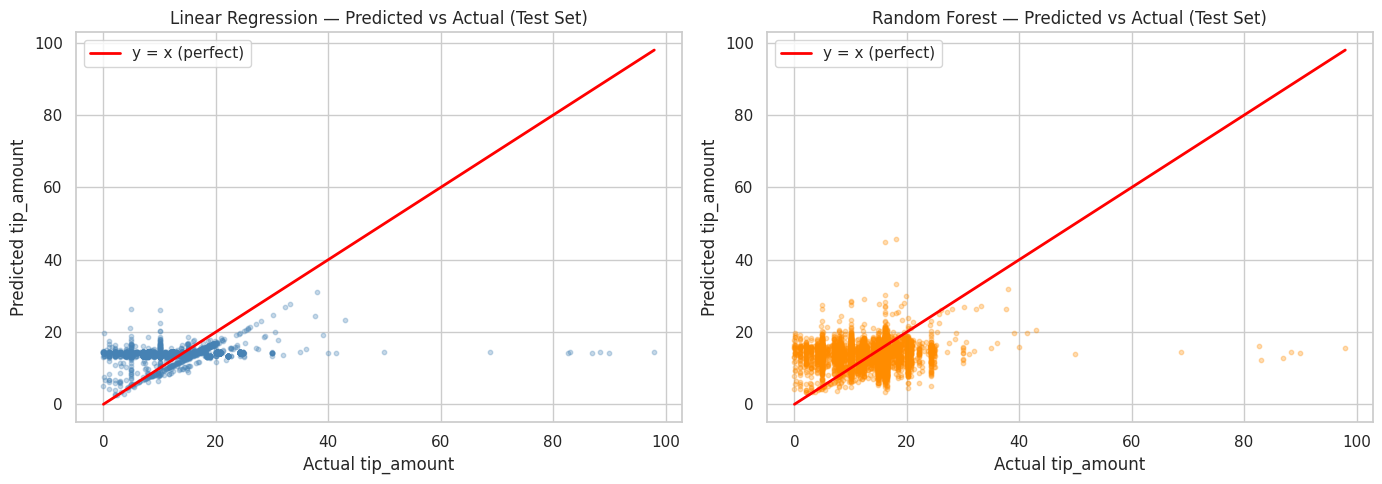

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    # Predict on all three splits
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    y_pred_test  = model.predict(X_test)

    # RMSE and R² for each split
    print(f"\n {name} ")
    for split, y_true, y_pred in [
        ("Train", y_train, y_pred_train),
        ("Val",   y_val,   y_pred_val),
        ("Test",  y_test,  y_pred_test),
    ]:
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2   = r2_score(y_true, y_pred)
        print(f"  {split:5s} RMSE: {rmse:.4f}  |  R²: {r2:.4f}")

    return y_pred_test
# TODO: Predict on train, validation, and test sets.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = evaluate_model(lr, X_train, y_train, X_val, y_val, X_test, y_test, "Linear Regression")


rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = evaluate_model(rf, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest")


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)


# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"],
    ["steelblue", "darkorange"]
):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color=color)
    lo, hi = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=2, label="y = x (perfect)")
    ax.set_xlabel("Actual tip_amount")
    ax.set_ylabel("Predicted tip_amount")
    ax.set_title(f"{name} — Predicted vs Actual (Test Set)")
    ax.legend()

plt.tight_layout()
plt.show()

#
Section 2 — Supervised Learning: Multi-class Classification

Part 2.1 — Load and explore the obesity data

Shape: (2111, 17)

 Head 


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



 Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                       

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



 Missing values per column 
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

 Class distribution of NObeyesdad 
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Imbalance ratio (max/min): 1.29x


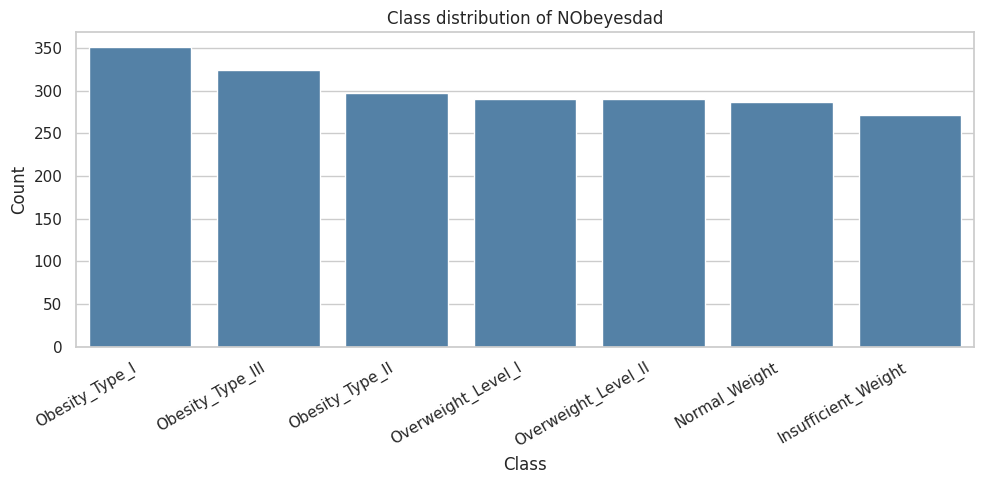

In [ ]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)


# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
print("\n Head ")
display(obesity.head())
print("\n Info ")
obesity.info()
print("\n Descriptive Statistics ")
display(obesity.describe())
print("\n Missing values per column ")
print(obesity.isna().sum())
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("\n Class distribution of NObeyesdad ")
counts = obesity["NObeyesdad"].value_counts()
print(counts)
print(f"\nImbalance ratio (max/min): {counts.iloc[0]/counts.iloc[-1]:.2f}x")


fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.countplot(data=obesity, x="NObeyesdad", order=counts.index, ax=ax, color="steelblue")
ax.set_title("Class distribution of NObeyesdad")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Part 2.2 — Preprocessing & feature engineering

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Reload the obesity dataset to ensure its original state before processing
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0}).fillna(0).astype(int)

print(" Binary encoding done ")
print(obesity[binary_cols].head())

caec_order = ["no", "Sometimes", "Frequently", "Always"]
calc_order = ["no", "Sometimes", "Frequently", "Always"]

# Ensure CAEC and CALC are string types before Ordinal Encoding
obesity["CAEC"] = obesity["CAEC"].astype(str)
obesity["CALC"] = obesity["CALC"].astype(str)

ordinal = OrdinalEncoder(categories=[caec_order, calc_order])
obesity[["CAEC", "CALC"]] = ordinal.fit_transform(obesity[["CAEC", "CALC"]])

print("\n Ordinal encoding done ")
print(obesity[["CAEC", "CALC"]].value_counts())

obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)

print("\n One-hot encoding done ")
print([c for c in obesity.columns if c.startswith("Gender") or c.startswith("MTRANS")])

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

print("\n BMI sample ")
print(obesity[["Weight", "Height", "BMI"]].head())

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obesity["NObeyesdad_encoded"] = le.fit_transform(obesity["NObeyesdad"])

print("\n Target encoding ")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

X = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y = obesity["NObeyesdad_encoded"]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes : {list(le.classes_)}")

 Binary encoding done 
   family_history_with_overweight  FAVC  SMOKE  SCC
0                               1     0      0    0
1                               1     0      1    1
2                               1     0      0    0
3                               0     0      0    0
4                               0     0      0    0

 Ordinal encoding done 
CAEC  CALC
1.0   1.0     1211
      0.0      509
2.0   1.0      120
      0.0      105
1.0   2.0       45
0.0   1.0       42
3.0   1.0       28
      0.0       18
2.0   2.0       16
3.0   2.0        7
0.0   0.0        7
      2.0        2
2.0   3.0        1
Name: count, dtype: int64

 One-hot encoding done 
['Gender_Male', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

 BMI sample 
   Weight  Height        BMI
0    64.0    1.62  24.386526
1    56.0    1.52  24.238227
2    77.0    1.80  23.765432
3    87.0    1.80  26.851852
4    89.8    1.78  28.342381

 Target encoding 
{'Insufficient_Weight':

Part 2.3 — Stratified Train / Validation / Test split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate X (features) and y (encoded NObeyesdad).

X = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y = obesity["NObeyesdad_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"\nTrain : {X_train.shape[0]:,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows ({len(X_test)/len(X)*100:.0f}%)")

print("\n Class proportions per split ")
splits = {"Train": y_train, "Val": y_val, "Test": y_test}
prop_df = pd.DataFrame({
    name: split.value_counts(normalize=True).sort_index()
    for name, split in splits.items()
})
prop_df.index = le.classes_
display(prop_df.round(3))



# TODO: Fit the scaler on the training set only, then transform train / val / test.

NUMERIC = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"]
NUMERIC = [c for c in NUMERIC if c in X_train.columns]

scaler = StandardScaler()
X_train[NUMERIC] = scaler.fit_transform(X_train[NUMERIC])
X_val[NUMERIC]   = scaler.transform(X_val[NUMERIC])
X_test[NUMERIC]  = scaler.transform(X_test[NUMERIC])

# Fill any remaining NaNs in the dataframes before model training
# This addresses the ValueError: Input X contains NaN in the next cell.
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

print("\n── Scaled training features (first 3 rows) ──")
display(X_train.head(3))

X shape: (2111, 20)
y shape: (2111,)

Train : 1,266 rows (60%)
Val   : 422 rows (20%)
Test  : 423 rows (20%)

 Class proportions per split 


,Train,Val,Test
Insufficient_Weight,0.129,0.130,0.128
Normal_Weight,0.136,0.135,0.137
Obesity_Type_I,0.167,0.166,0.165
Obesity_Type_II,0.141,0.140,0.142
Obesity_Type_III,0.153,0.154,0.154
Overweight_Level_I,0.137,0.137,0.137
Overweight_Level_II,0.137,0.137,0.137



── Scaled training features (first 3 rows) ──


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI
632,-0.824396,-1.745146,-1.712321,0,0,0.958514,0.019564,2.0,0,-1.109239,1,1.038839,-0.466807,1.0,False,False,False,True,False,-1.498533
1112,0.472822,1.430955,0.419265,1,1,0.931068,-1.732899,1.0,0,-0.110783,0,1.103636,0.574933,1.0,True,False,False,True,False,-0.091798
285,-0.513676,0.943376,0.703507,1,1,-0.805113,0.397063,3.0,0,-1.655362,0,-1.194873,-1.081180,1.0,True,False,False,True,False,0.382195


Part 2.4 — Train a classifier and check for overfitting


 Logistic Regression 
  Train → Accuracy: 0.9281  |  Macro-F1: 0.9258
  Val   → Accuracy: 0.8839  |  Macro-F1: 0.8779
  Test  → Accuracy: 0.9007  |  Macro-F1: 0.8972

 Random Forest 
  Train → Accuracy: 1.0000  |  Macro-F1: 1.0000
  Val   → Accuracy: 0.9929  |  Macro-F1: 0.9925
  Test  → Accuracy: 0.9953  |  Macro-F1: 0.9955

 Classification Report: Logistic Regression (Test) 
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        54
      Normal_Weight       0.93      0.72      0.82        58
     Obesity_Type_I       0.96      0.94      0.95        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.72      0.81      0.76        58
Overweight_Level_II       0.83      0.83      0.83        58

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       

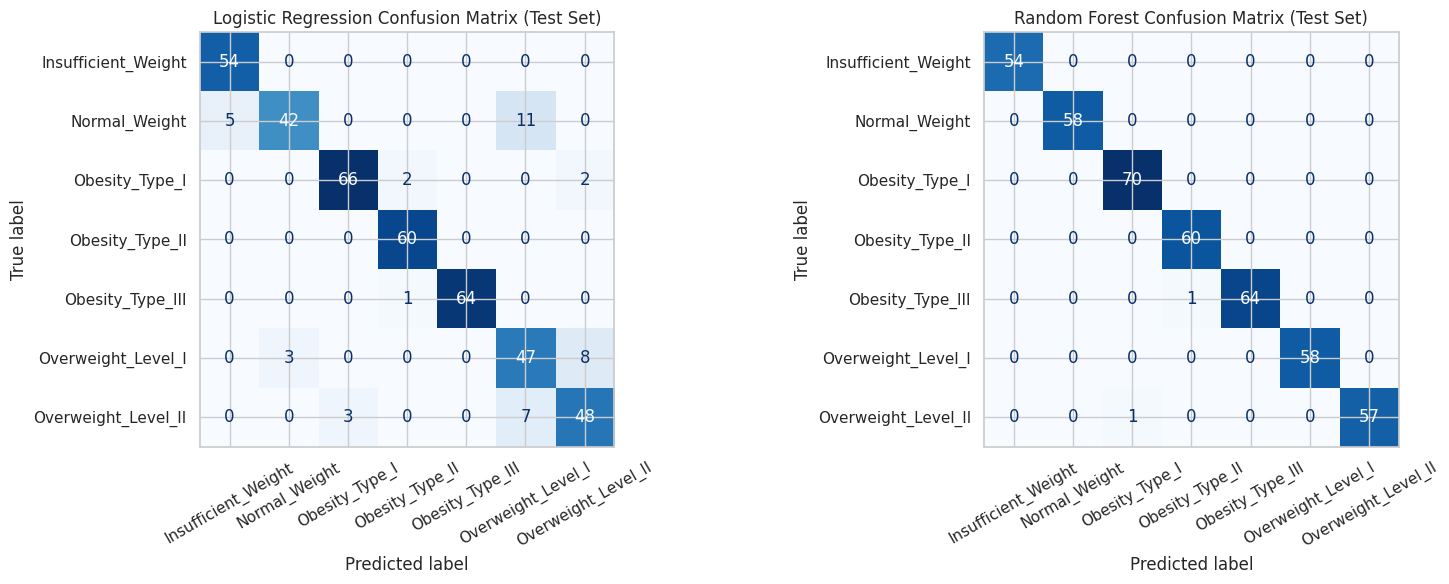

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name):

    preds = {
        "Train" : model.predict(X_train),
        "Val"   : model.predict(X_val),
        "Test"  : model.predict(X_test),
    }
    truths = {"Train": y_train, "Val": y_val, "Test": y_test}

    print(f"\n {name} ")
    for split in ["Train", "Val", "Test"]:
        acc = accuracy_score(truths[split], preds[split])
        f1  = f1_score(truths[split], preds[split], average="macro")
        print(f"  {split:5s} → Accuracy: {acc:.4f}  |  Macro-F1: {f1:.4f}")

    return preds["Test"]

# TODO: Predict on train, validation, and test.

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
lr_test_preds = evaluate_model(lr, X_train, y_train,
                                     X_val, y_val, X_test, y_test,
                                     "Logistic Regression")

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_test_preds = evaluate_model(rf, X_train, y_train,
                                     X_val, y_val, X_test, y_test,
                                     "Random Forest")

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

print("\n Classification Report: Logistic Regression (Test) ")
print(classification_report(y_test, lr_test_preds, target_names=le.classes_))

print("\n Classification Report:Random Forest (Test) ")
print(classification_report(y_test, rf_test_preds, target_names=le.classes_))

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, name in zip(
    axes,
    [lr_test_preds, rf_test_preds],
    ["Logistic Regression", "Random Forest"]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=le.classes_,
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=30
    )
    ax.set_title(f"{name} Confusion Matrix (Test Set)")

plt.tight_layout()
plt.show()

# Section 3 — Unsupervised Learning: K-Means Clustering

Part 3.1 — Choose k, fit K-Means, and visualise

Clustering feature matrix shape: (2111, 20)
  k=2  inertia=18109.3  silhouette=0.1610
  k=3  inertia=16284.1  silhouette=0.1589
  k=4  inertia=14867.3  silhouette=0.1728
  k=5  inertia=13753.0  silhouette=0.1601
  k=6  inertia=12856.5  silhouette=0.1586
  k=7  inertia=12287.4  silhouette=0.1579
  k=8  inertia=11779.4  silhouette=0.1542
  k=9  inertia=11381.7  silhouette=0.1553
  k=10  inertia=10998.0  silhouette=0.1595


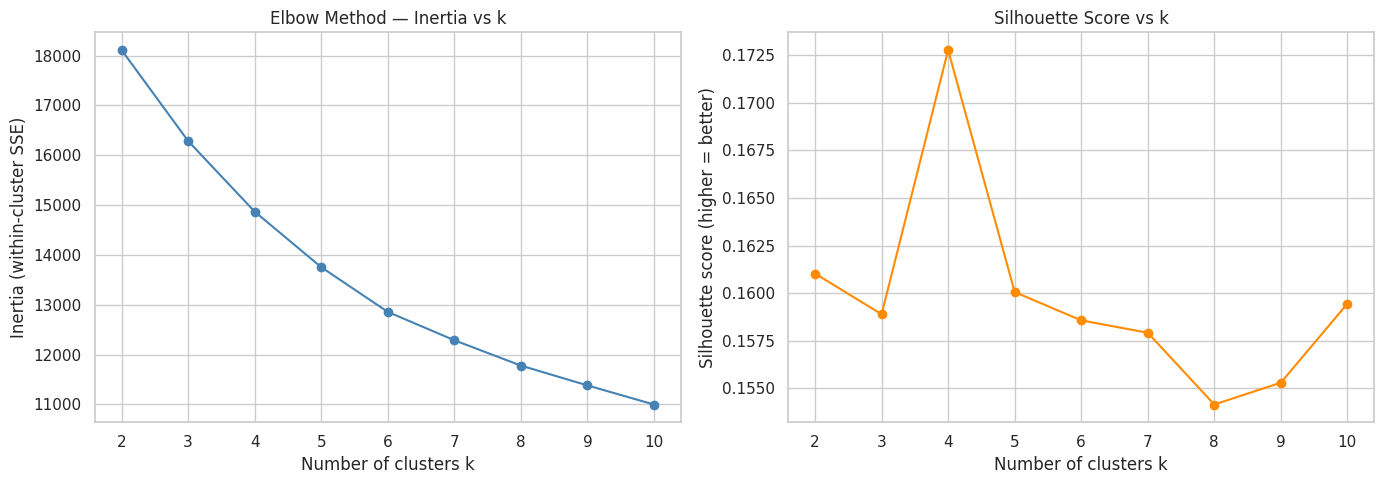


Chosen k = 7
Cluster sizes:
0    298
1    388
2    338
3    285
4    288
5    261
6    253
Name: count, dtype: int64

PCA explained variance ratio: [0.23726808 0.1656704 ]
Total variance captured: 40.3%


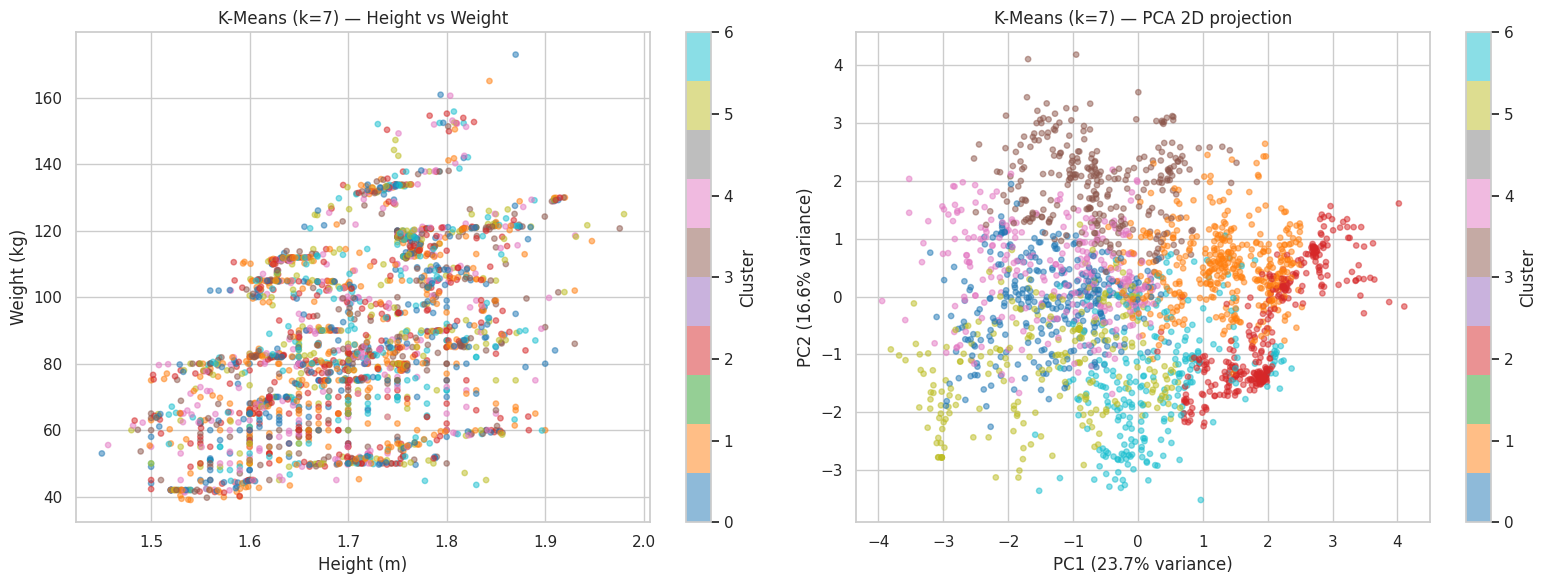

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = pd.concat([X_train, X_val, X_test], ignore_index=True)

print("Clustering feature matrix shape:", X_cluster.shape)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
k_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

axes[1].plot(k_range, sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score (higher = better)")

plt.tight_layout()
plt.show()
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
CHOSEN_K = 7

km_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)

print(f"\nChosen k = {CHOSEN_K}")
print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

# Option A: Weight vs Height (intuitive, domain-meaningful)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reconstruct original (unscaled) Weight and Height for interpretable axes
y_all = pd.concat([y_train, y_val, y_test], ignore_index=True)
obesity_full = pd.read_csv(OBESITY_URL)

axes[0].scatter(
    obesity_full["Height"], obesity_full["Weight"],
    c=cluster_labels, cmap="tab10", alpha=0.5, s=15
)
axes[0].set_xlabel("Height (m)")
axes[0].set_ylabel("Weight (kg)")
axes[0].set_title(f"K-Means (k={CHOSEN_K}) — Height vs Weight")
plt.colorbar(axes[0].collections[0], ax=axes[0], label="Cluster")

# Option B: PCA : 2D (captures maximum variance)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum()*100:.1f}%")

axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.5, s=15
)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title(f"K-Means (k={CHOSEN_K}) — PCA 2D projection")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

 Crosstab: Cluster vs True Obesity Level 


True Obesity Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,79,98,30,2,0,52,37
1,0,3,115,202,0,17,51
2,0,0,1,13,324,0,0
3,90,66,30,0,0,55,44
4,60,64,45,0,0,56,63
5,42,47,50,28,0,64,30
6,1,9,80,52,0,46,65



 Normalised (row %) — dominant class per cluster 


True Obesity Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,0.265,0.329,0.101,0.007,0.000,0.174,0.124
1,0.000,0.008,0.296,0.521,0.000,0.044,0.131
2,0.000,0.000,0.003,0.038,0.959,0.000,0.000
3,0.316,0.232,0.105,0.000,0.000,0.193,0.154
4,0.208,0.222,0.156,0.000,0.000,0.194,0.219
5,0.161,0.180,0.192,0.107,0.000,0.245,0.115
6,0.004,0.036,0.316,0.206,0.000,0.182,0.257



 Best matching obesity level per cluster 
  Cluster 0 → Normal_Weight                   (purity: 32.9%)
  Cluster 1 → Obesity_Type_II                 (purity: 52.1%)
  Cluster 2 → Obesity_Type_III                (purity: 95.9%)
  Cluster 3 → Insufficient_Weight             (purity: 31.6%)
  Cluster 4 → Normal_Weight                   (purity: 22.2%)
  Cluster 5 → Overweight_Level_I              (purity: 24.5%)
  Cluster 6 → Obesity_Type_I                  (purity: 31.6%)


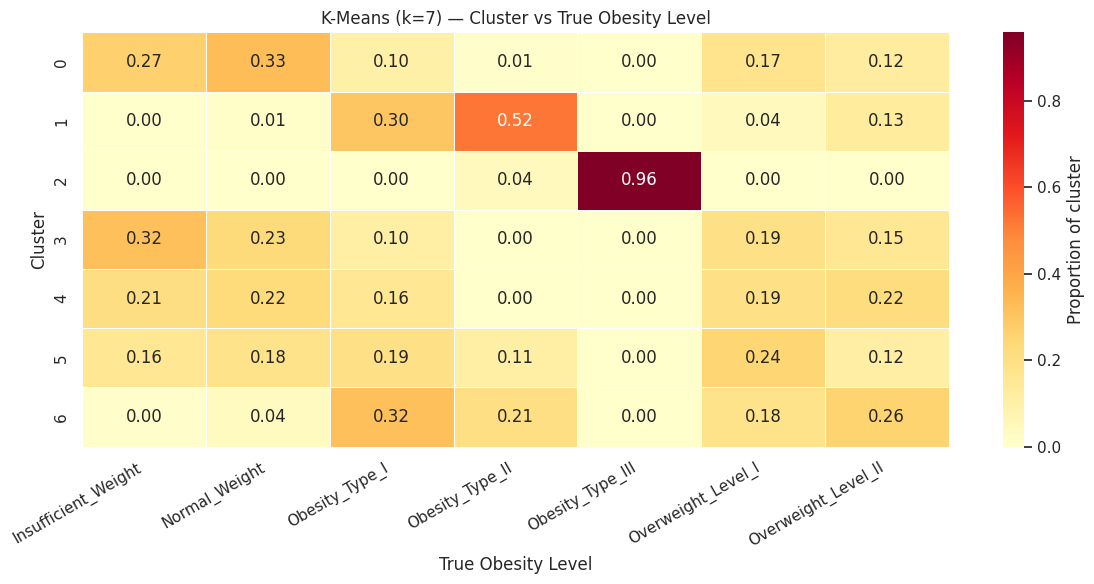


Overall clustering purity: 0.4368
(1.0 = perfect alignment with true labels, 0.0 = random)


In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?

#  Reconstruct full target (same order as X_cluster)
y_all        = pd.concat([y_train, y_val, y_test], ignore_index=True)
obesity_full = pd.read_csv(OBESITY_URL)
true_labels  = pd.concat([
    pd.Series(obesity_full["NObeyesdad"].values[y_train.index]),
    pd.Series(obesity_full["NObeyesdad"].values[y_val.index]),
    pd.Series(obesity_full["NObeyesdad"].values[y_test.index]),
], ignore_index=True)

# CROSSTAB: cluster vs true obesity level

ct = pd.crosstab(
    cluster_labels,
    true_labels,
    rownames=["Cluster"],
    colnames=["True Obesity Level"]
)
print(" Crosstab: Cluster vs True Obesity Level ")
display(ct)

# NORMALISED CROSSTAB (row %) — what does each cluster mostly contain?
ct_norm = ct.div(ct.sum(axis=1), axis=0).round(3)
print("\n Normalised (row %) — dominant class per cluster ")
display(ct_norm)

#  DOMINANT LABEL PER CLUSTER
print("\n Best matching obesity level per cluster ")
for cluster in sorted(ct.index):
    dominant = ct.loc[cluster].idxmax()
    purity   = ct_norm.loc[cluster].max()
    print(f"  Cluster {cluster} → {dominant:30s}  (purity: {purity:.1%})")

# HEATMAP OF NORMALISED CROSSTAB
plt.figure(figsize=(12, 6))
sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Proportion of cluster"}
)
plt.title(f"K-Means (k={CHOSEN_K}) — Cluster vs True Obesity Level")
plt.xlabel("True Obesity Level")
plt.ylabel("Cluster")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# OVERALL PURITY SCORE
# Purity = sum of dominant class counts / total points
purity_score = ct.max(axis=1).sum() / len(cluster_labels)
print(f"\nOverall clustering purity: {purity_score:.4f}")
print("(1.0 = perfect alignment with true labels, 0.0 = random)")


# Section 4 — Reflection



1.   Supervised vs unsupervised: What did the classifier learn that K-Means could set not, and vice-versa?

The classifier learned explicit decision boundaries from labels, allowing it to distinguish between similar adjacent classes like Overweight_Level_I and Overweight_Level_II. K-Means could not do this without labels it blurred those boundaries. However, K-Means didn't need labels at all, meaning it could still find meaningful structure in entirely new, unlabeled data something the classifier is useless for without a labeled training

2.   Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

In regression, metrics like RMSE and R² measured how far off predictions were a $3.50 prediction on a $4.00 tip is nearly right, and the metric reflects that closeness. In classification, predictions are either the correct class or not there is no "almost right." This is why we used Accuracy and Macro-F1 instead, and added a confusion matrix to see which classes were being mixed up, something RMSE has no equivalent for.


3.   Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?







